In [2]:
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from pathlib import Path
from collections import Counter
from PIL import Image

import torch
from ultralytics import YOLO
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

# Seed
import random
random.seed(42)
np.random.seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device       : {device}")
if device == "cuda":
    print(f"GPU          : {torch.cuda.get_device_name(0)}")

import ultralytics
print(f"Ultralytics  : {ultralytics.__version__}")
print(f"PyTorch      : {torch.__version__}")

Device       : cpu
Ultralytics  : 8.4.23
PyTorch      : 2.8.0+cpu


## Access Dataset

In [3]:
DATA_ROOT = Path("../Bone_Fracture_Binary_Classification")

# Verify structure
for split in ["train", "val", "test"]:
    split_path = DATA_ROOT / split
    if split_path.exists():
        classes = [d.name for d in split_path.iterdir() if d.is_dir()]
        counts  = {c: len(list((split_path / c).glob("*.*"))) for c in classes}
        print(f"{split:5s}: {counts}")

train: {'fractured': 4606, 'not fractured': 4640}
val  : {'fractured': 337, 'not fractured': 492}
test : {'fractured': 238, 'not fractured': 268}


## EDA

Classes: ['fractured', 'not fractured']

train: {'fractured': 4606, 'not fractured': 4640}  (total: 9246)
val  : {'fractured': 337, 'not fractured': 492}  (total: 829)
test : {'fractured': 238, 'not fractured': 268}  (total: 506)


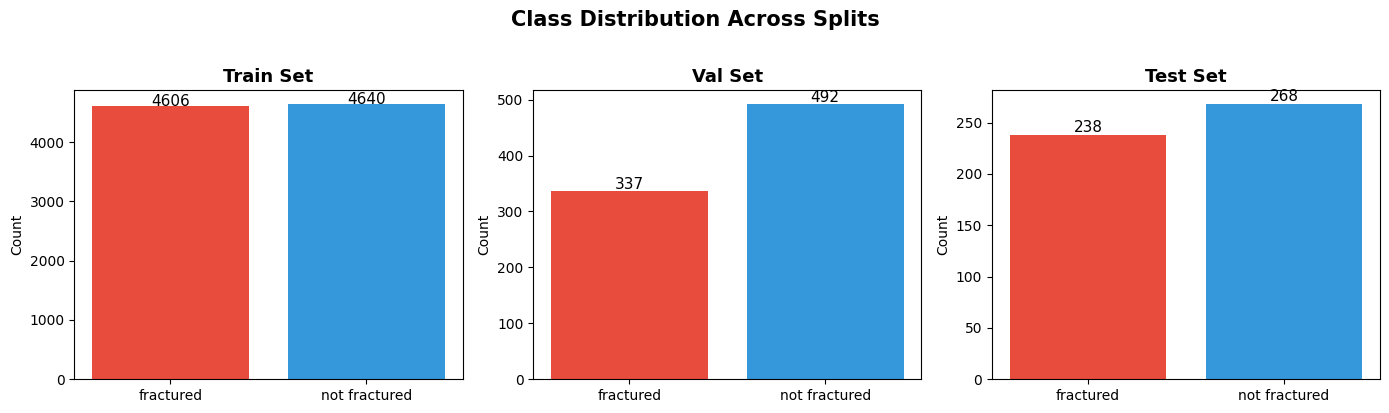

In [4]:
# Class counts per split
splits      = ["train", "val", "test"]
class_names = sorted([d.name for d in (DATA_ROOT / "train").iterdir() if d.is_dir()])

split_counts = {}
for split in splits:
    split_counts[split] = {
        cls: len(list((DATA_ROOT / split / cls).glob("*.*")))
        for cls in class_names
    }

print(f"Classes: {class_names}\n")
for split, counts in split_counts.items():
    total = sum(counts.values())
    print(f"{split:5s}: {counts}  (total: {total})")

# Bar chart
palette = ["#E74C3C", "#3498DB"]
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, split in zip(axes, splits):
    counts = split_counts[split]
    bars   = ax.bar(counts.keys(), counts.values(), color=palette)
    ax.set_title(f"{split.capitalize()} Set", fontsize=13, fontweight="bold")
    ax.set_ylabel("Count")
    for bar, val in zip(bars, counts.values()):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3,
                str(val), ha="center", fontsize=11)

plt.suptitle("Class Distribution Across Splits", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

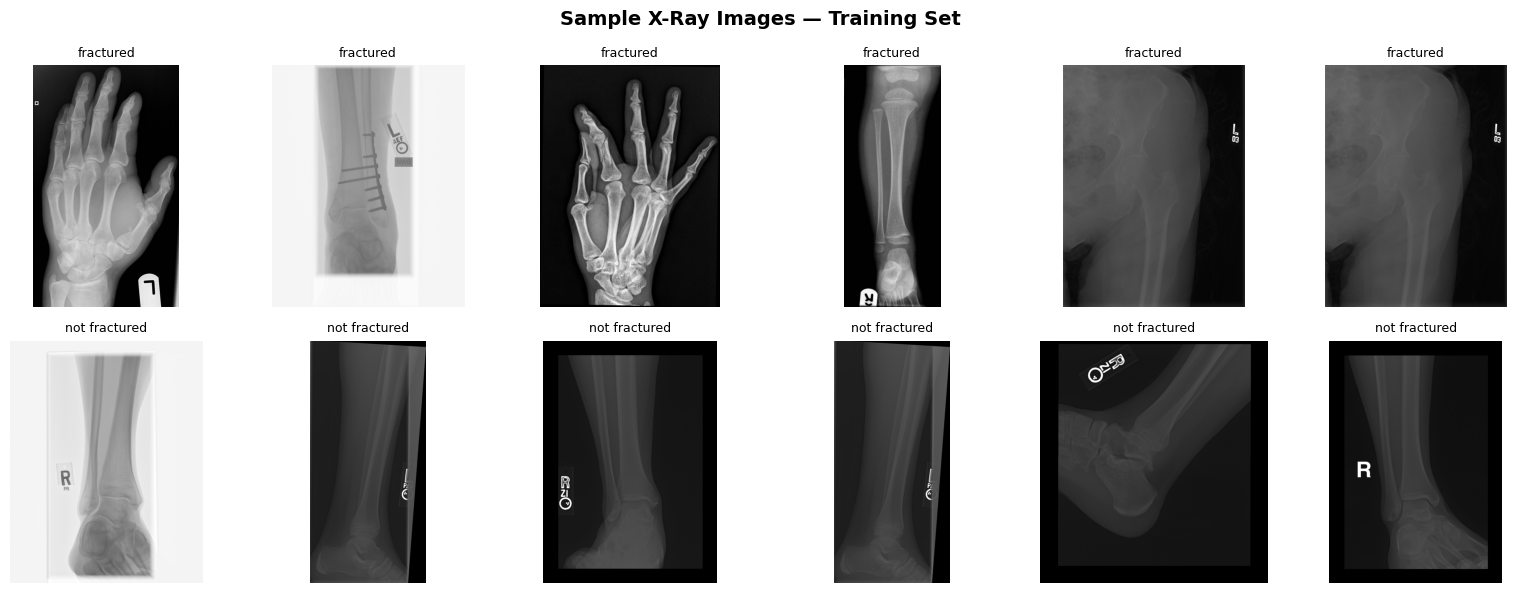

In [5]:
# Sample images grid
fig, axes = plt.subplots(2, 6, figsize=(16, 6))
fig.suptitle("Sample X-Ray Images — Training Set", fontsize=14, fontweight="bold")

for row, cls in enumerate(class_names):
    img_paths = list((DATA_ROOT / "train" / cls).glob("*.*"))[:6]
    for col, path in enumerate(img_paths):
        img = Image.open(path).convert("RGB")
        axes[row][col].imshow(img)
        axes[row][col].set_title(cls, fontsize=9)
        axes[row][col].axis("off")

plt.tight_layout()
plt.show()

## Select YOLO model

In [8]:
MODEL_SIZE = "yolov8m-cls"

# Load pretrained ImageNet weights
model = YOLO(f"{MODEL_SIZE}.pt")
print(f"Loaded: {MODEL_SIZE}")
print(model.info())

Loaded: yolov8m-cls
YOLOv8m-cls summary: 80 layers, 17,053,336 parameters, 0 gradients, 42.9 GFLOPs
(80, 17053336, 0, 42.9150208)


## Training

In [ ]:
# Hyperparameters
EPOCHS     = 30       
IMG_SIZE   = 224
BATCH_SIZE = 32
LR         = 1e-3     # Initial learning rate
PROJECT    = "runs/fracture_classify"
RUN_NAME   = MODEL_SIZE

# Train
results = model.train(
    data      = str(DATA_ROOT),
    epochs    = EPOCHS,
    imgsz     = IMG_SIZE,
    batch     = BATCH_SIZE,
    lr0       = LR,
    device    = device,
    project   = PROJECT,
    name      = RUN_NAME,
    exist_ok  = True,
    patience  = 10,       # Early stopping if val accuracy plateaus
    augment   = True,     # Built-in Ultralytics augmentation
    verbose   = True,
)

print("\nTraining complete!")
print(f"Best model saved to: {PROJECT}/{RUN_NAME}/weights/best.pt")

Ultralytics 8.4.23  Python-3.10.18 torch-2.8.0+cpu CPU (11th Gen Intel Core i7-1165G7 @ 2.80GHz)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=..\Bone_Fracture_Binary_Classification, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8m-cls, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=

KeyboardInterrupt: 

## Training Curves

In [ ]:
import pandas as pd

run_dir  = Path(PROJECT) / RUN_NAME
csv_path = run_dir / "results.csv"

if csv_path.exists():
    df_log = pd.read_csv(csv_path)
    df_log.columns = df_log.columns.str.strip()   # remove whitespace from col names
    print("Columns in results.csv:", list(df_log.columns))
    print(df_log.tail())
else:
    print(f"results.csv not found at {csv_path}")

NameError: name 'history' is not defined

In [ ]:
col_map = {}
for col in df_log.columns:
    c = col.lower()
    if "train" in c and "loss" in c:    col_map["train_loss"] = col
    if "val"   in c and "loss" in c:    col_map["val_loss"]   = col
    if "train" in c and "acc" in c:     col_map["train_acc"]  = col
    if "val"   in c and "acc" in c:     col_map["val_acc"]    = col

print("Mapped columns:", col_map)

epochs = df_log["epoch"] if "epoch" in df_log.columns else range(1, len(df_log) + 1)
color  = "#E74C3C"

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
if "train_loss" in col_map and "val_loss" in col_map:
    axes[0].plot(epochs, df_log[col_map["train_loss"]], "--", color=color, alpha=0.6, label="Train")
    axes[0].plot(epochs, df_log[col_map["val_loss"]],   "-",  color=color, lw=2,     label="Val")
axes[0].set_title("Loss", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
if "train_acc" in col_map and "val_acc" in col_map:
    axes[1].plot(epochs, df_log[col_map["train_acc"]], "--", color=color, alpha=0.6, label="Train")
    axes[1].plot(epochs, df_log[col_map["val_acc"]],   "-",  color=color, lw=2,     label="Val")

    best_idx   = df_log[col_map["val_acc"]].idxmax()
    best_epoch = df_log.loc[best_idx, "epoch"] if "epoch" in df_log.columns else best_idx + 1
    best_acc   = df_log[col_map["val_acc"]].max()
    axes[1].axvline(best_epoch, color="gray", linestyle=":", alpha=0.8)
    axes[1].annotate(
        f"Best: {best_acc:.3f}\n(epoch {int(best_epoch)})",
        xy=(best_epoch, best_acc),
        xytext=(best_epoch + 1, best_acc - 0.05),
        arrowprops=dict(arrowstyle="->", color="gray"),
        fontsize=9, color="gray"
    )

axes[1].set_title("Accuracy", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle(f"{MODEL_SIZE} — Training Curves", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
# Display results.png 
results_png = run_dir / "results.png"
if results_png.exists():
    img = mpimg.imread(results_png)
    plt.figure(figsize=(14, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Ultralytics Results Summary", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("results.png not found — check run directory")

## Evaluate on test

In [ ]:
best_weights = run_dir / "weights" / "best.pt"
best_model   = YOLO(str(best_weights))
print(f"Loaded best weights from: {best_weights}")

# Validate on the test split
test_metrics = best_model.val(
    data    = str(DATA_ROOT),
    split   = "test",
    imgsz   = IMG_SIZE,
    batch   = BATCH_SIZE,
    device  = device,
    verbose = True,
)

print("\nTest results:")
print(test_metrics)

## Get predictions for analysis

In [ ]:
# Gather all test images with their true labels
test_dir    = DATA_ROOT / "test"
class_names = sorted([d.name for d in test_dir.iterdir() if d.is_dir()])
class_to_idx = {c: i for i, c in enumerate(class_names)}

test_images  = []
true_labels  = []

for cls in class_names:
    for img_path in sorted((test_dir / cls).glob("*.*")):
        test_images.append(str(img_path))
        true_labels.append(class_to_idx[cls])

print(f"Total test images: {len(test_images)}")
print(f"Classes: {class_names}")

In [ ]:
# Run inference in batches
all_preds  = []
all_probs  = []
INFER_BATCH = 64

for i in range(0, len(test_images), INFER_BATCH):
    batch_paths = test_images[i : i + INFER_BATCH]
    results_batch = best_model.predict(
        batch_paths,
        imgsz   = IMG_SIZE,
        device  = device,
        verbose = False,
    )
    for r in results_batch:
        probs = r.probs.data.cpu().numpy()   
        all_probs.append(probs)
        all_preds.append(int(probs.argmax()))

all_preds  = np.array(all_preds)
all_probs  = np.array(all_probs)
true_labels = np.array(true_labels)

# Map YOLO's internal class order to our class_names order
yolo_classes = best_model.names   
print("YOLO class mapping:", yolo_classes)

acc = (all_preds == true_labels).mean()
print(f"\nTest Accuracy: {acc:.4f} ({acc*100:.2f}%)")

In [ ]:
# Full classification report
print(classification_report(true_labels, all_preds, target_names=class_names))

## Confusion matrix

In [ ]:
cm   = confusion_matrix(true_labels, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title(f"{MODEL_SIZE} — Confusion Matrix (Test Set)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## ROC Curve

In [ ]:
POSITIVE_CLASS = class_names.index("fractured") if "fractured" in class_names else 0

y_score       = all_probs[:, POSITIVE_CLASS]
y_true_binary = (true_labels == POSITIVE_CLASS).astype(int)
fpr, tpr, _   = roc_curve(y_true_binary, y_score)
auc           = roc_auc_score(y_true_binary, y_score)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr, tpr, color="#E74C3C", lw=2, label=f"{MODEL_SIZE} (AUC = {auc:.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Test Set", fontsize=13, fontweight="bold")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"AUC: {auc:.4f}")

## View Misclassifications

In [ ]:
wrong_idx = np.where(all_preds != true_labels)[0][:12]

if len(wrong_idx) == 0:
    print("No misclassifications on the test set!")
else:
    cols = 6
    rows = (len(wrong_idx) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.5, rows * 2.8))
    axes = axes.flatten()

    for ax, idx in zip(axes, wrong_idx):
        img = Image.open(test_images[idx]).convert("RGB")
        ax.imshow(img)
        true_lbl = class_names[true_labels[idx]]
        pred_lbl = class_names[all_preds[idx]]
        conf     = all_probs[idx][all_preds[idx]]
        ax.set_title(f"True: {true_lbl}\nPred: {pred_lbl} ({conf:.0%})",
                     fontsize=8, color="red")
        ax.axis("off")

    for ax in axes[len(wrong_idx):]:
        ax.axis("off")

    plt.suptitle("Misclassified Samples", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()
    print(f"Total misclassified: {len(wrong_idx)} / {len(test_images)}")

## Inference on Single Image

In [ ]:
def predict_single(model, image_path, class_names=class_names):
    result = model.predict(str(image_path), imgsz=IMG_SIZE, device=device, verbose=False)[0]
    probs  = result.probs.data.cpu().numpy()
    pred   = int(probs.argmax())
    conf   = probs[pred]

    label_color = "green" if class_names[pred] == "non-fractured" else "red"

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(Image.open(image_path).convert("RGB"))
    axes[0].axis("off")
    axes[0].set_title(
        f"Prediction: {class_names[pred]}\nConfidence: {conf:.2%}",
        fontsize=12, fontweight="bold", color=label_color
    )
    axes[1].barh(class_names, probs, color=["#E74C3C", "#2ECC71"])
    axes[1].set_xlim(0, 1)
    axes[1].set_xlabel("Probability")
    axes[1].set_title("Class Probabilities")
    axes[1].grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()

    return class_names[pred], probs


# First test image
sample_path = test_images[0]
true_cls    = class_names[true_labels[0]]
print(f"Image      : {sample_path}")
print(f"True label : {true_cls}")
predict_single(best_model, sample_path)